<a href="https://colab.research.google.com/github/SASI136/CODTECH-Task-1/blob/main/project_e_waste_detection_and.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir('/content/drive')

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']

In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['project e waste detection',
 'project',
 'mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top(1).h5',
 'e_waste_model_mobilenetv2.h5',
 'e_waste_model.keras']

In [ ]:
import os
os.listdir('/content/drive/MyDrive/project')

['e-waste management']

In [6]:
import os

base_path = '/content/drive/MyDrive/project/e-waste management'

print(os.listdir(base_path))

['val', 'test', 'train']


In [7]:
print(os.listdir(base_path + '/train'))

['Washing Machine', 'Player', 'Mouse', 'Printer', 'PCB', 'Television', 'Microwave', 'Mobile', 'Keyboard', 'Battery']


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [9]:
train_data = train_datagen.flow_from_directory(
    base_path + '/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    base_path + '/val',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 2400 images belonging to 10 classes.
Found 300 images belonging to 10 classes.


In [10]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),   # 🔥 important
    layers.Dense(10, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 520s 7s/step - accuracy: 0.8454 - loss: 0.4761 - val_accuracy: 0.9233 - val_loss: 0.2289
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.8867 - loss: 0.3678 - val_accuracy: 0.9267 - val_loss: 0.1943
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.8921 - loss: 0.3260 - val_accuracy: 0.9267 - val_loss: 0.1998
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9154 - loss: 0.2701 - val_accuracy: 0.9233 - val_loss: 0.1930
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9271 - loss: 0.2410 - val_accuracy: 0.9367 - val_loss: 0.1889
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.9221 - loss: 0.2526 - val_accuracy: 0.9367 - val_loss: 0.1749
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9287 - loss: 0.2215 - val_accuracy: 0.9367 - val_loss: 0.1598
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.9358 - loss: 0.1986 - val_accuracy: 0.9267 - v

In [18]:
model.save("e_waste_model.keras")

In [19]:
print("Final Train Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

print("Final Train Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

Final Train Accuracy: 0.9470833539962769
Final Validation Accuracy: 0.9399999976158142
Final Train Loss: 0.16144391894340515
Final Validation Loss: 0.18405760824680328


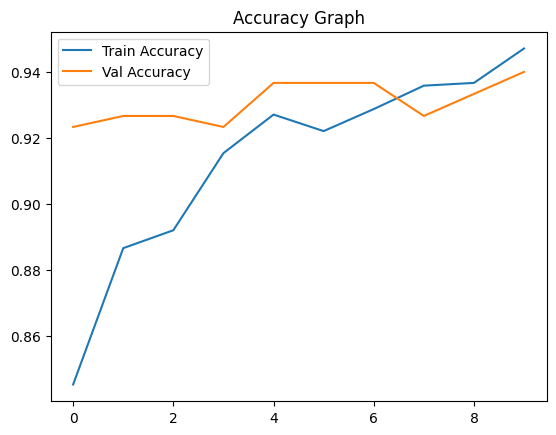

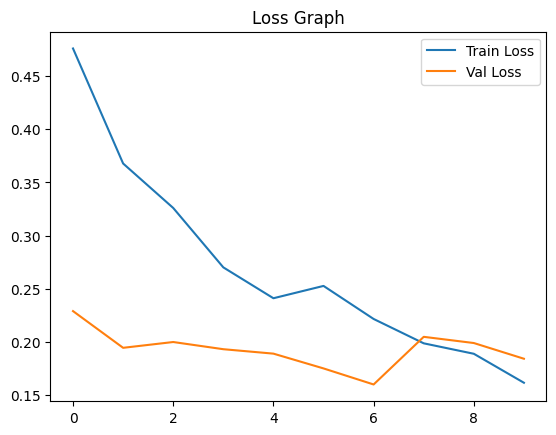

In [20]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

In [ ]:
model.save("e_waste_model.keras")

NameError: name 'model' is not defined

In [21]:
import os
os.listdir("/content/drive/MyDrive/project/e-waste management/test")

['Printer',
 'Television',
 'Washing Machine',
 'PCB',
 'Player',
 'Mobile',
 'Mouse',
 'Microwave',
 'Keyboard',
 'Battery']

In [22]:
import os

test_path = "/content/drive/MyDrive/project/e-waste management/test"
print(os.listdir(test_path))

['Printer', 'Television', 'Washing Machine', 'PCB', 'Player', 'Mobile', 'Mouse', 'Microwave', 'Keyboard', 'Battery']


In [23]:
img_path = "/content/drive/MyDrive/project/e-waste management/test/IMG_001.jpg"

In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Get a list of class folders in the test directory
class_folders = os.listdir(test_path)

# Choose one class folder to pick an image from (e.g., 'Mobile')
# For demonstration, we'll pick the first class folder that is not empty.
selected_class_folder = None
for folder in class_folders:
    folder_path = os.path.join(test_path, folder)
    if os.path.isdir(folder_path):
        images_in_folder = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        if images_in_folder:
            selected_class_folder = folder
            img_name = images_in_folder[0]
            break

if selected_class_folder is None:
    print("No image files found in any class folder in the test directory.")
else:
    img_path = os.path.join(test_path, selected_class_folder, img_name)

    print(f"Attempting to predict on image: {img_path}")

    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    predicted_class_index = np.argmax(prediction, axis=1)

    # Map to actual class label
    class_labels = {v:k for k,v in train_data.class_indices.items()}
    predicted_label = class_labels[predicted_class_index[0]]

    print("Predicted Class:", predicted_label)

Attempting to predict on image: /content/drive/MyDrive/project/e-waste management/test/Printer/Printer_284.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class: Printer


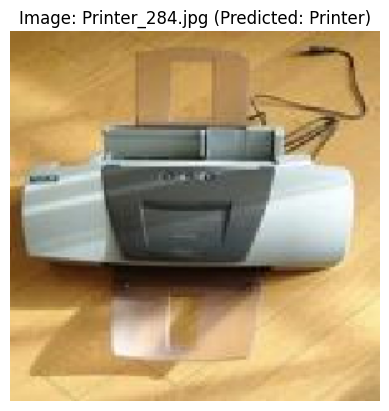

In [27]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Image: {img_name} (Predicted: {predicted_label})")
plt.axis('off')
plt.show()

In [28]:
import random
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

# Number of images to display in the grid
num_images_to_display = 9 # You can change this

selected_images_info = []

# Get a list of all class folders in the test directory
class_folders = [f for f in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, f))]

if not class_folders:
    print("No class folders found in the test directory.")
else:
    # Collect a list of all image paths from all class folders
    all_image_paths = []
    for folder in class_folders:
        folder_path = os.path.join(test_path, folder)
        images_in_folder = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        all_image_paths.extend(images_in_folder)

    if not all_image_paths:
        print("No image files found in the test directory.")
    else:
        # Randomly select images
        random.shuffle(all_image_paths)
        images_to_predict = all_image_paths[:num_images_to_display]

        print(f"Selected {len(images_to_predict)} random images for prediction.")

        for img_path_single in images_to_predict:
            # Load and preprocess image
            img_single = image.load_img(img_path_single, target_size=(224,224))
            img_array_single = image.img_to_array(img_single)/255.0
            img_array_single = np.expand_dims(img_array_single, axis=0)

            # Predict
            prediction_single = model.predict(img_array_single, verbose=0)
            predicted_class_index_single = np.argmax(prediction_single, axis=1)

            # Map to actual class label
            class_labels = {v:k for k,v in train_data.class_indices.items()}
            predicted_label_single = class_labels[predicted_class_index_single[0]]

            selected_images_info.append({
                'path': img_path_single,
                'image': img_single,
                'predicted_label': predicted_label_single
            })

        print("Predictions completed for selected images.")

Selected 9 random images for prediction.
Predictions completed for selected images.


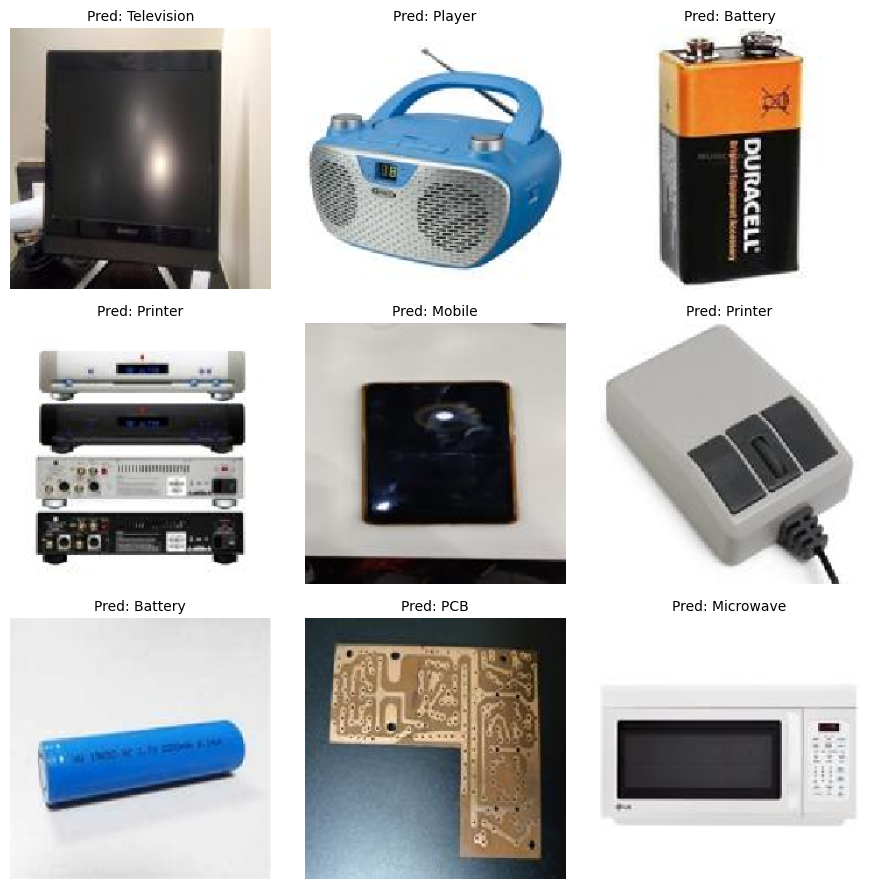

In [29]:
if selected_images_info:
    # Calculate grid dimensions (e.g., 3x3 for 9 images)
    num_images = len(selected_images_info)
    rows = int(np.ceil(np.sqrt(num_images)))
    cols = int(np.ceil(num_images / rows))

    plt.figure(figsize=(cols * 3, rows * 3))

    for i, img_info in enumerate(selected_images_info):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_info['image'])
        # Extract the image name from the path for display
        img_name_display = os.path.basename(img_info['path'])
        plt.title(f"Pred: {img_info['predicted_label']}", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No images to display.")

In [30]:
model.save("ewaste_model.keras")

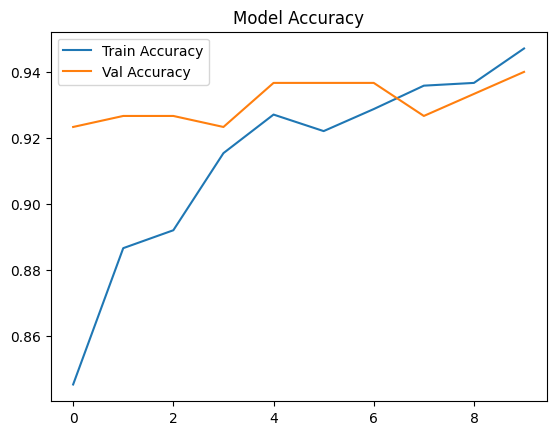

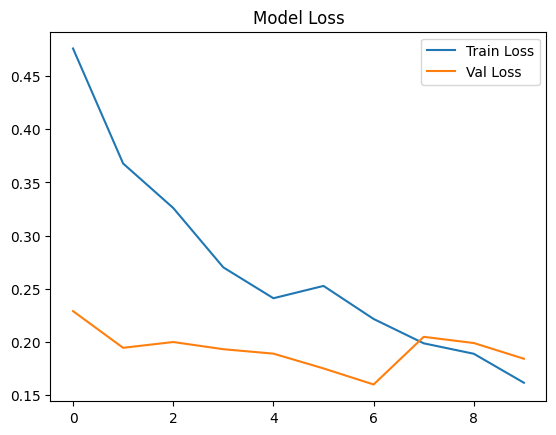

In [31]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Model Loss")
plt.show()


In [32]:
import os

test_path = '/content/drive/MyDrive/project/e-waste management/test'
print(os.listdir(test_path))

['Printer', 'Television', 'Washing Machine', 'PCB', 'Player', 'Mobile', 'Mouse', 'Microwave', 'Keyboard', 'Battery']


In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/project/e-waste management/test',  # ⚠️ correct path
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 300 images belonging to 10 classes.


In [34]:
print(test_generator.class_indices)

{'Battery': 0, 'Keyboard': 1, 'Microwave': 2, 'Mobile': 3, 'Mouse': 4, 'PCB': 5, 'Player': 6, 'Printer': 7, 'Television': 8, 'Washing Machine': 9}


In [35]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 167s 18s/step - accuracy: 0.9400 - loss: 0.1851
Test Accuracy: 0.9399999976158142
Test Loss: 0.1851457953453064


In [36]:
model.save("/content/drive/MyDrive/project/ewaste_model.keras")